# Eksperimen SML - ihdamawa
## Dataset: Heart Disease (Kaggle)

Dataset ini berisi informasi medis pasien untuk memprediksi apakah seseorang menderita penyakit jantung atau tidak. Merupakan masalah klasifikasi biner yang sangat populer di dunia machine learning.

**Sumber:** [Kaggle - Heart Disease](https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset/data) 
**Target:** `target` (1 = penyakit jantung, 0 = tidak)

---

## 1. Perkenalan Dataset

Dataset Heart Disease UCI memiliki 14 atribut:
- `age`: Umur pasien
- `sex`: Jenis kelamin (1 = laki-laki, 0 = perempuan)
- `cp`: Tipe nyeri dada (0–3)
- `trestbps`: Tekanan darah saat istirahat (mm Hg)
- `chol`: Kadar kolesterol (mg/dl)
- `fbs`: Gula darah puasa > 120 mg/dl (1 = true, 0 = false)
- `restecg`: Hasil elektrokardiografi saat istirahat (0–2)
- `thalach`: Detak jantung maksimum
- `exang`: Angina akibat olahraga (1 = ya, 0 = tidak)
- `oldpeak`: Depresi ST akibat olahraga
- `slope`: Kemiringan puncak ST (0–2)
- `ca`: Jumlah pembuluh darah utama (0–3)
- `thal`: Hasil tes thalassemia (0–3)
- `target`: Label (1 = sakit jantung, 0 = sehat)

## 2. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

print('Library berhasil diimport!')

Library berhasil diimport!


## 3. Memuat Dataset

In [2]:
# Memuat dataset dari file CSV
df = pd.read_csv('../heart_raw.csv')

print(f'Ukuran dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Ukuran dataset: (1025, 14)
Jumlah baris: 1025
Jumlah kolom: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
# Informasi tipe data dan non-null count
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


In [4]:
# Statistik deskriptif
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


## 4. Exploratory Data Analysis (EDA)

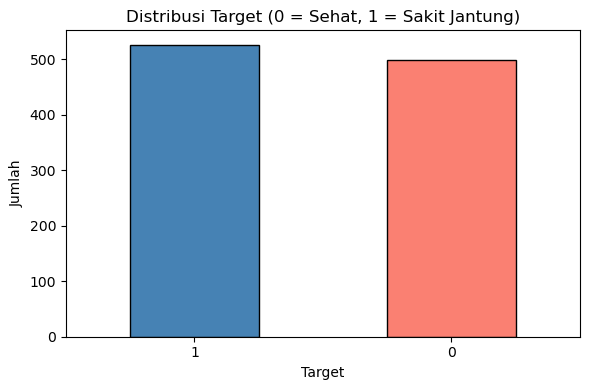

target
1    526
0    499
Name: count, dtype: int64

Rasio kelas:
target
1    0.51
0    0.49
Name: proportion, dtype: float64


In [5]:
# Distribusi kelas target
plt.figure(figsize=(6, 4))
df['target'].value_counts().plot(kind='bar', color=['steelblue', 'salmon'], edgecolor='black')
plt.title('Distribusi Target (0 = Sehat, 1 = Sakit Jantung)')
plt.xlabel('Target')
plt.ylabel('Jumlah')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

print(df['target'].value_counts())
print(f'\nRasio kelas:\n{df["target"].value_counts(normalize=True).round(2)}')

In [6]:
# Cek missing values
print('=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else 'Tidak ada missing values')
print(f'\nTotal missing: {df.isnull().sum().sum()}')

=== Missing Values ===
Tidak ada missing values

Total missing: 0


In [7]:
# Cek duplikasi
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')

Jumlah baris duplikat: 723


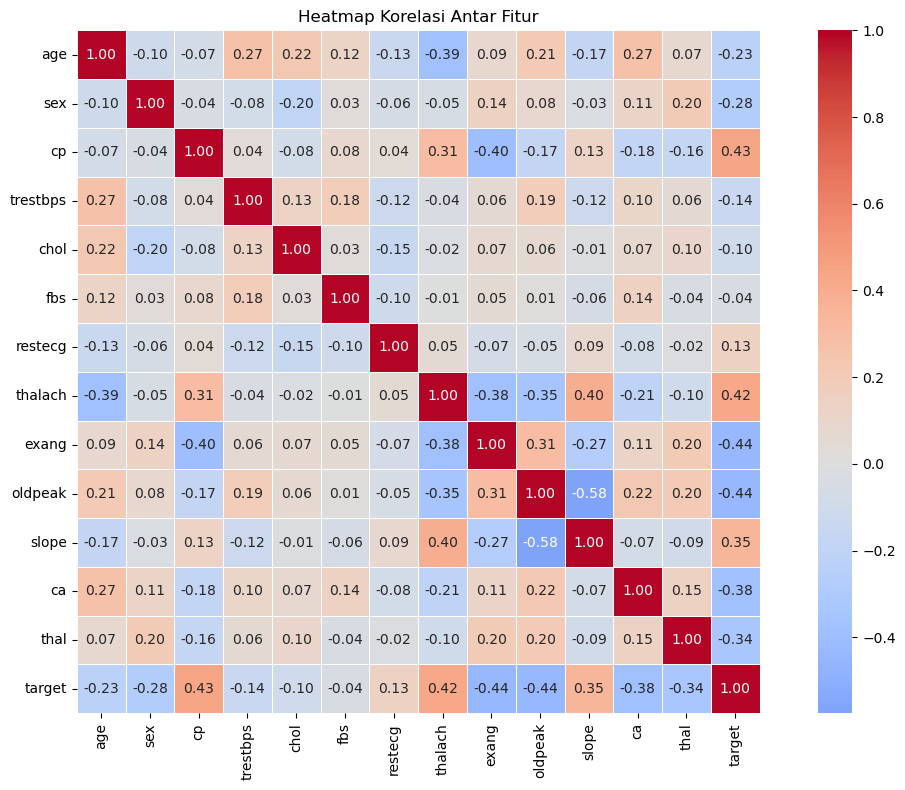

In [8]:
# Heatmap korelasi
plt.figure(figsize=(12, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5)
plt.title('Heatmap Korelasi Antar Fitur')
plt.tight_layout()
plt.show()

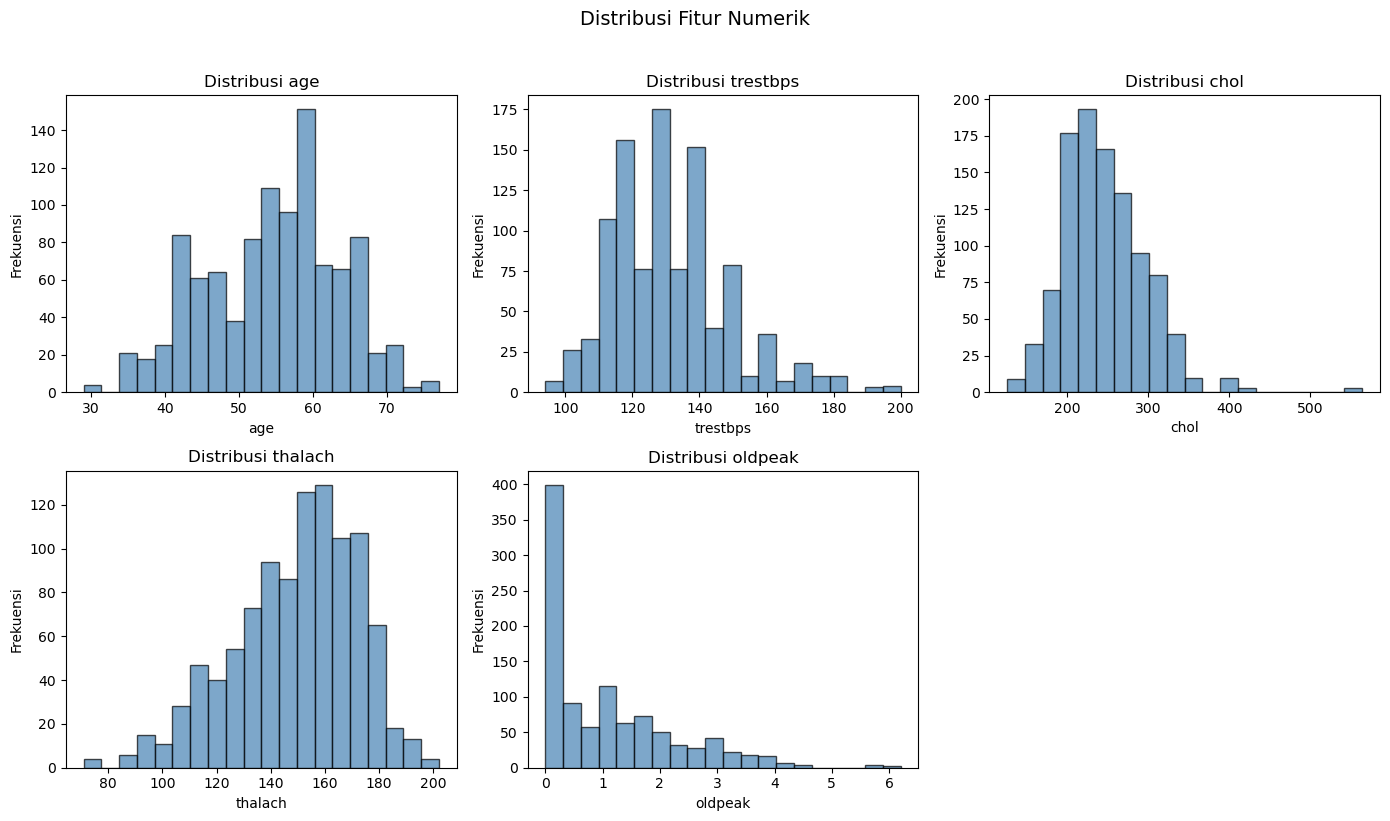

In [9]:
# Distribusi fitur numerik
numerical_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].hist(df[col], bins=20, color='steelblue', edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frekuensi')

axes[-1].axis('off')
plt.suptitle('Distribusi Fitur Numerik', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

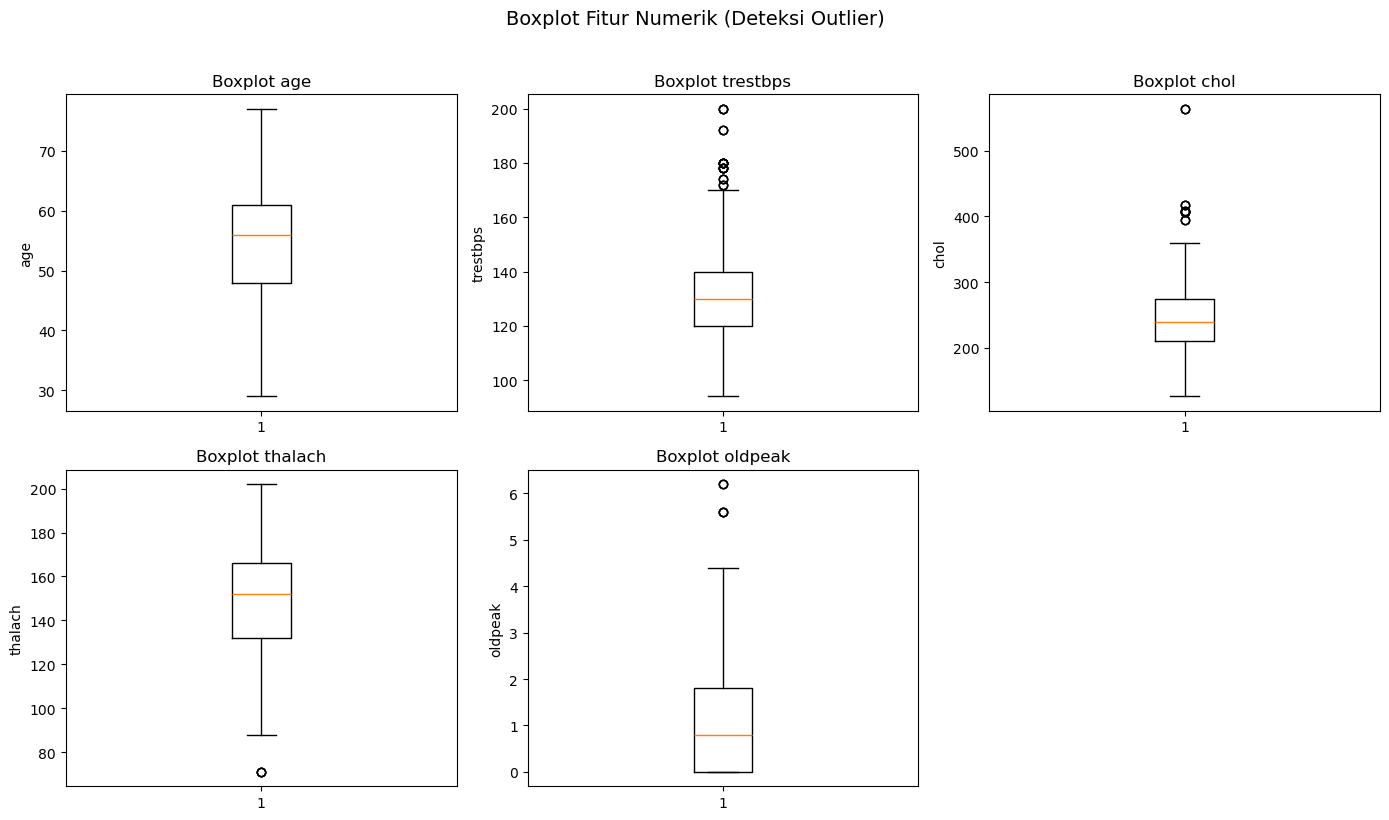

In [10]:
# Boxplot untuk deteksi outlier
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    axes[i].boxplot(df[col])
    axes[i].set_title(f'Boxplot {col}')
    axes[i].set_ylabel(col)

axes[-1].axis('off')
plt.suptitle('Boxplot Fitur Numerik (Deteksi Outlier)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

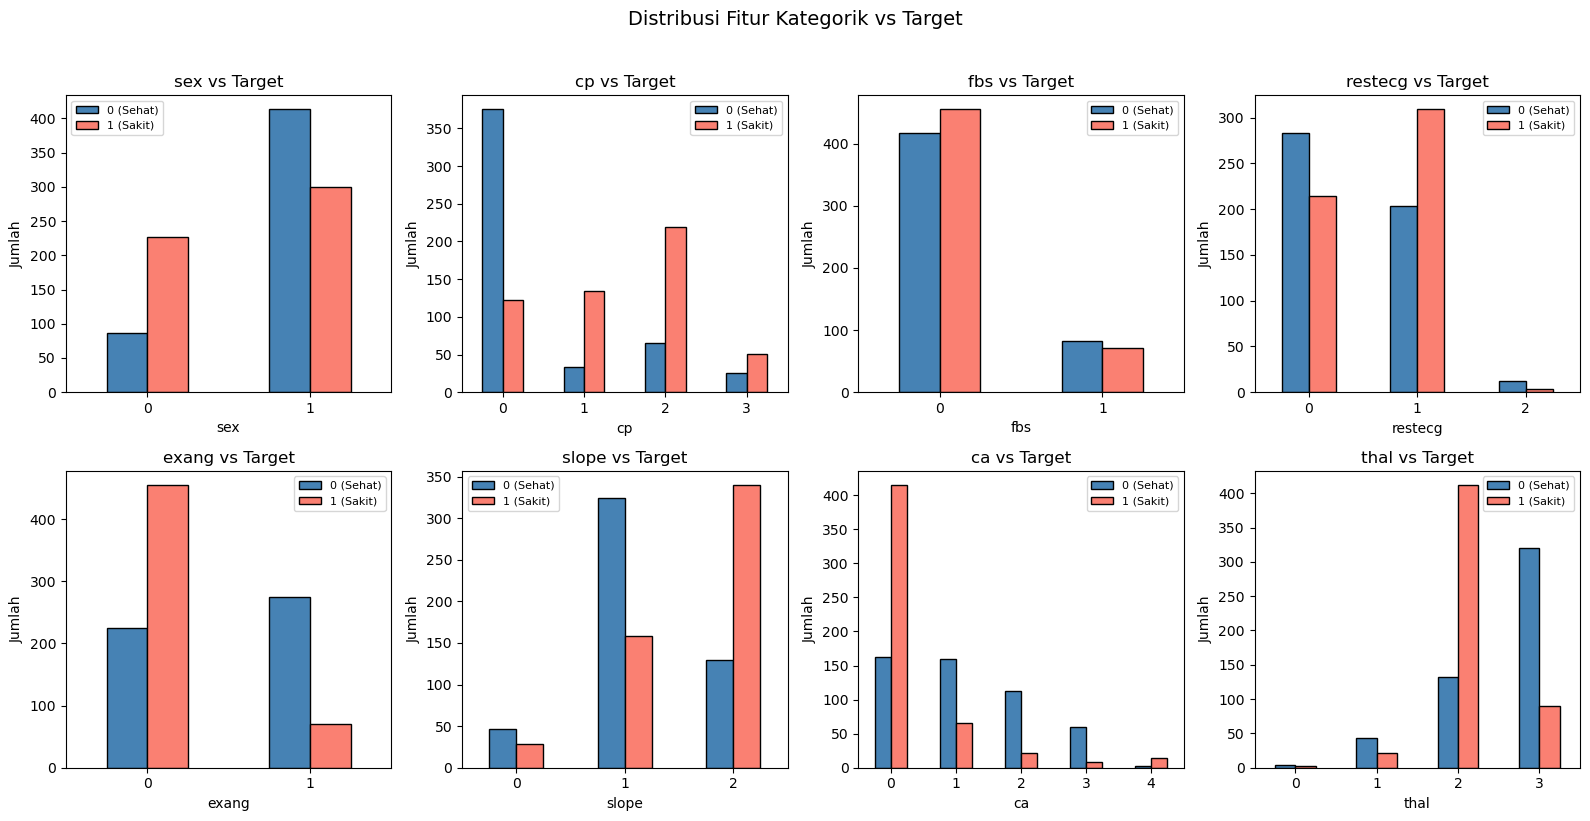

In [11]:
# Distribusi fitur kategorik berdasarkan target
categorical_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    df.groupby([col, 'target']).size().unstack().plot(
        kind='bar', ax=axes[i], color=['steelblue', 'salmon'], edgecolor='black'
    )
    axes[i].set_title(f'{col} vs Target')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=0)
    axes[i].legend(['0 (Sehat)', '1 (Sakit)'], fontsize=8)

plt.suptitle('Distribusi Fitur Kategorik vs Target', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### Ringkasan EDA

- Dataset memiliki **303 baris** dan **14 kolom** (13 fitur + 1 target)
- **Tidak ada missing values** pada dataset ini
- Terdapat **1 baris duplikat** yang perlu dihapus
- Fitur `chol` dan `trestbps` memiliki beberapa **outlier** berdasarkan IQR
- Dataset relatif **seimbang** antara kelas 0 dan 1
- Fitur seperti `cp`, `thalach`, dan `ca` menunjukkan korelasi cukup kuat dengan target

## 5. Data Preprocessing

In [12]:
# Salin dataframe agar data original tetap bersih
df_clean = df.copy()
print(f'Shape awal: {df_clean.shape}')

Shape awal: (1025, 14)


In [13]:
# --- 5.1 Menghapus Data Duplikat ---
print(f'Sebelum hapus duplikat: {df_clean.shape}')
df_clean = df_clean.drop_duplicates()
print(f'Setelah hapus duplikat: {df_clean.shape}')

Sebelum hapus duplikat: (1025, 14)
Setelah hapus duplikat: (302, 14)


In [14]:
# --- 5.2 Menangani Missing Values ---
# Dataset ini tidak memiliki missing values, namun kita tangani sebagai best practice
print(f'Missing values per kolom:\n{df_clean.isnull().sum()}')

# Untuk kolom numerik: isi dengan median (lebih robust terhadap outlier)
numerical_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != 'target']

for col in numerical_cols:
    if df_clean[col].isnull().sum() > 0:
        median_val = df_clean[col].median()
        df_clean[col].fillna(median_val, inplace=True)
        print(f'  {col}: diisi dengan median={median_val}')

print('\nMissing values setelah penanganan:')
print(df_clean.isnull().sum())

Missing values per kolom:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

Missing values setelah penanganan:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


In [15]:
# --- 5.3 Deteksi dan Penanganan Outlier dengan IQR ---
# Hanya pada kolom numerik kontinu
outlier_cols = ['trestbps', 'chol', 'thalach', 'oldpeak']

print('=== Deteksi Outlier (IQR Method) ===')
for col in outlier_cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    outliers = df_clean[(df_clean[col] < lower) | (df_clean[col] > upper)]
    print(f'{col}: Q1={Q1}, Q3={Q3}, IQR={IQR:.2f}, Lower={lower:.2f}, Upper={upper:.2f}, Outlier={len(outliers)}')
    # Cap outlier (Winsorizing)
    df_clean[col] = df_clean[col].clip(lower=lower, upper=upper)

print(f'\nShape setelah penanganan outlier: {df_clean.shape}')

=== Deteksi Outlier (IQR Method) ===
trestbps: Q1=120.0, Q3=140.0, IQR=20.00, Lower=90.00, Upper=170.00, Outlier=9
chol: Q1=211.0, Q3=274.75, IQR=63.75, Lower=115.38, Upper=370.38, Outlier=5
thalach: Q1=133.25, Q3=166.0, IQR=32.75, Lower=84.12, Upper=215.12, Outlier=1
oldpeak: Q1=0.0, Q3=1.6, IQR=1.60, Lower=-2.40, Upper=4.00, Outlier=5

Shape setelah penanganan outlier: (302, 14)


In [16]:
# --- 5.4 Encoding Data Kategorikal ---
# Kolom kategorik yang perlu di-encode: cp, restecg, slope, thal (ordinal/nominal)
# Karena semua sudah dalam format numerik (integer), kita pastikan tipe datanya benar

categorical_int_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

for col in categorical_int_cols:
    df_clean[col] = df_clean[col].astype(int)

print('Tipe data setelah encoding:')
print(df_clean.dtypes)

Tipe data setelah encoding:
age           int64
sex           int64
cp            int64
trestbps      int64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object


In [17]:
# --- 5.5 Normalisasi / Standarisasi Fitur ---
# Pisahkan fitur dan target
X = df_clean.drop('target', axis=1)
y = df_clean['target']

# Kolom yang perlu distandarisasi (fitur kontinu)
scale_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

scaler = StandardScaler()
X[scale_cols] = scaler.fit_transform(X[scale_cols])

print('Statistik setelah standarisasi:')
print(X[scale_cols].describe().round(3))

Statistik setelah standarisasi:
           age  trestbps     chol  thalach  oldpeak
count  302.000   302.000  302.000  302.000  302.000
mean    -0.000     0.000   -0.000   -0.000    0.000
std      1.002     1.002    1.002    1.002    1.002
min     -2.814    -2.247   -2.518   -2.881   -0.927
25%     -0.711    -0.679   -0.725   -0.720   -0.927
50%      0.120    -0.076   -0.103    0.127   -0.206
75%      0.728     0.527    0.620    0.721    0.516
max      2.500     2.337    2.637    2.305    2.681


In [18]:
# --- 5.6 Train-Test Split ---
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'X_train shape : {X_train.shape}')
print(f'X_test shape  : {X_test.shape}')
print(f'y_train shape : {y_train.shape}')
print(f'y_test shape  : {y_test.shape}')

X_train shape : (241, 13)
X_test shape  : (61, 13)
y_train shape : (241,)
y_test shape  : (61,)


In [20]:
# --- 5.7 Simpan Dataset Hasil Preprocessing ---
import os
os.makedirs('../heart_preprocessing', exist_ok=True)

# Gabungkan kembali X dan y sebelum simpan
df_preprocessed = X.copy()
df_preprocessed['target'] = y.values

# Simpan train dan test set
train_df = X_train.copy()
train_df['target'] = y_train.values

test_df = X_test.copy()
test_df['target'] = y_test.values

train_df.to_csv('../heart_preprocessing/heart_train.csv', index=False)
test_df.to_csv('../heart_preprocessing/heart_test.csv', index=False)
df_preprocessed.to_csv('../heart_preprocessing/heart_preprocessed.csv', index=False)

print('Dataset preprocessing berhasil disimpan!')
print(f'  - heart_preprocessed.csv : {df_preprocessed.shape}')
print(f'  - heart_train.csv        : {train_df.shape}')
print(f'  - heart_test.csv         : {test_df.shape}')

Dataset preprocessing berhasil disimpan!
  - heart_preprocessed.csv : (302, 14)
  - heart_train.csv        : (241, 14)
  - heart_test.csv         : (61, 14)


In [21]:
# Preview hasil akhir
print('=== Preview Data Hasil Preprocessing ===')
df_preprocessed.head()

=== Preview Data Hasil Preprocessing ===


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,-0.267966,1,0,-0.377511,-0.704039,0,1,0.808993,0,-0.025091,2,2,3,0
1,-0.157260,1,0,0.527318,-0.893880,1,0,0.237018,1,1.869266,0,0,3,0
2,1.724733,1,0,0.828927,-1.505591,0,1,-1.082925,1,1.418229,0,0,3,0
3,0.728383,1,0,1.009893,-0.893880,0,1,0.501006,0,-0.927166,2,1,3,0
4,0.839089,0,0,0.406674,1.025627,1,1,-1.918889,0,0.786777,1,3,2,0
